## 1. Setup & Imports

In [1]:
# ============================================================
# CONFIGURATION
# ============================================================

# No configuration needed for this cell

# ============================================================
# CODE
# ============================================================

import sys
from pathlib import Path

# Get project root (parent of Pipelines folder)
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project Root: {PROJECT_ROOT}")

Project Root: d:\Project\FootballAnalytix


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

# No configuration needed for this cell

# ============================================================
# CODE
# ============================================================

# Import the modular library
from footballanalytix import (
    # Config
    PROJECT_ROOT as LIB_ROOT,
    MODELS_DIR,
    DATASET_DIR,
    CONFIDENCE_THRESHOLD,
    TEAM_COLORS_BGR,
    
    # Models
    load_players_model,
    load_field_model,
    
    # State
    CombinedState,
    
    # Field
    SoccerPitchConfiguration,
    
    # Pipeline
    create_state_from_frame,
    initialize_combined_state,
    process_combined_frame,
    
    # Visualization
    draw_pitch,
    compose_split_view,
)

import cv2
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from IPython.display import Video, display

print(f"Library Root: {LIB_ROOT}")
print(f"Models Dir: {MODELS_DIR}")
print(f"Dataset Dir: {DATASET_DIR}")
print("\n✅ All imports successful!")

Library Root: D:\Project\FootballAnalytix
Models Dir: D:\Project\FootballAnalytix\Models
Dataset Dir: D:\Project\FootballAnalytix\Data\Sample

✅ All imports successful!


---

## 2. Load Models

In [3]:
# ============================================================
# CONFIGURATION
# ============================================================

# Path to the players detection model (None = use default)
PLAYERS_MODEL_PATH = None  # e.g., r"D:\Models\Players.pt"

# Path to the field keypoint detection model (None = use default)
FIELD_MODEL_PATH = None  # e.g., r"D:\Models\Fields.pt"

# ============================================================
# CODE
# ============================================================

# Load models using the library functions
players_model = load_players_model(model_path=PLAYERS_MODEL_PATH)
field_model = load_field_model(model_path=FIELD_MODEL_PATH)

print("\n✅ Models loaded successfully!")

Loaded players model from D:\Project\FootballAnalytix\Models\Players.pt
Loaded field model from D:\Project\FootballAnalytix\Models\Fields.pt

✅ Models loaded successfully!


---

## 3. Initialize Pitch Configuration

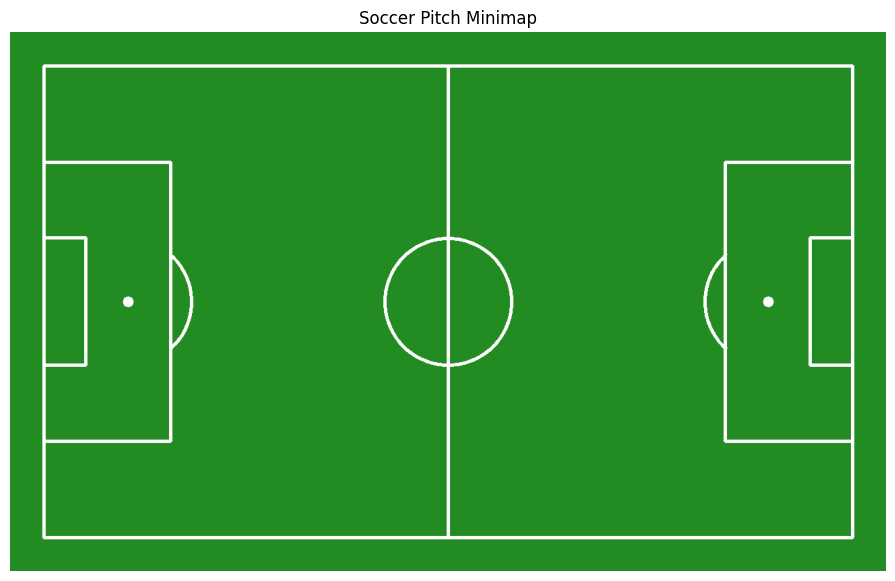


Pitch dimensions: 12000 x 7000
Number of keypoints: 29


In [4]:
# ============================================================
# CONFIGURATION
# ============================================================

# Soccer pitch dimensions (in internal units)
PITCH_LENGTH = 12000
PITCH_WIDTH = 7000
PENALTY_BOX_LENGTH = 1886
PENALTY_BOX_WIDTH = 4140
GOAL_BOX_LENGTH = 629
GOAL_BOX_WIDTH = 1885
CENTER_CIRCLE_RADIUS = 942
PENALTY_SPOT_DISTANCE = 1257

# ============================================================
# CODE
# ============================================================

# Create pitch configuration
pitch_config = SoccerPitchConfiguration(
    length=PITCH_LENGTH,
    width=PITCH_WIDTH,
    penalty_box_length=PENALTY_BOX_LENGTH,
    penalty_box_width=PENALTY_BOX_WIDTH,
    goal_box_length=GOAL_BOX_LENGTH,
    goal_box_width=GOAL_BOX_WIDTH,
    centre_circle_radius=CENTER_CIRCLE_RADIUS,
    penalty_spot_distance=PENALTY_SPOT_DISTANCE,
)

# Draw base minimap
base_minimap = draw_pitch(pitch_config)

# Display the minimap
plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(base_minimap, cv2.COLOR_BGR2RGB))
plt.title("Soccer Pitch Minimap")
plt.axis("off")
plt.show()

print(f"\nPitch dimensions: {pitch_config.length} x {pitch_config.width}")
print(f"Number of keypoints: {len(pitch_config.vertices)}")

---

## 4. Process a Single Image

In [5]:
# ============================================================
# CONFIGURATION
# ============================================================

# Path to a single image file to process
# Set to None to auto-detect from dataset
IMAGE_PATH = None  # e.g., r"D:\Project\FootballAnalytix\Data\Sample\SNGS-131\Frames\000500.jpg"

# Detection confidence threshold (0.0 - 1.0)
IMAGE_CONFIDENCE = 0.65

# Visualization options
SHOW_OBJECT_DETECTION = True
SHOW_TEAM_CLUSTERING = True
SHOW_PLAYER_IDS = True
SHOW_DETECTED_KEYPOINTS = True

# ============================================================
# CODE
# ============================================================

# Auto-detect image if not specified
if IMAGE_PATH is None:
    frames_dir = DATASET_DIR / "SNGS-131" / "Frames"
    if frames_dir.exists():
        sample_images = sorted(list(frames_dir.glob("*.jpg")))
        if sample_images:
            IMAGE_PATH = str(sample_images[len(sample_images) // 2])
            print(f"Auto-detected image: {IMAGE_PATH}")
        else:
            print("❌ No .jpg images found in frames directory")
    else:
        print(f"❌ Frames directory not found: {frames_dir}")

if IMAGE_PATH:
    image_path = Path(IMAGE_PATH)
    if image_path.exists():
        print(f"Processing: {image_path}")
    else:
        print(f"❌ Image not found: {image_path}")
        IMAGE_PATH = None

Auto-detected image: D:\Project\FootballAnalytix\Data\Sample\SNGS-131\Frames\000376.jpg
Processing: D:\Project\FootballAnalytix\Data\Sample\SNGS-131\Frames\000376.jpg


In [6]:
# ============================================================
# CONFIGURATION
# ============================================================

# Uses configuration from previous cell

# ============================================================
# CODE
# ============================================================

if IMAGE_PATH:
    # Load image
    frame = cv2.imread(str(IMAGE_PATH))
    print(f"Image shape: {frame.shape}")
    
    # Create state from single frame
    state = create_state_from_frame(frame, players_model, conf=IMAGE_CONFIDENCE)
    
    # Process the frame
    result = process_combined_frame(
        frame=frame,
        frame_idx=0,
        state=state,
        players_model=players_model,
        field_model=field_model,
        config=pitch_config,
        conf=IMAGE_CONFIDENCE,
        show_object_detection=SHOW_OBJECT_DETECTION,
        show_clustering=SHOW_TEAM_CLUSTERING,
        show_id=SHOW_PLAYER_IDS,
        show_detected_vertices=SHOW_DETECTED_KEYPOINTS,
        base_minimap=base_minimap.copy(),
    )
    
    print(f"\n📊 Detection Stats:")
    print(f"   Team 0: {result['stats']['team_0']} players")
    print(f"   Team 1: {result['stats']['team_1']} players")
    print(f"   Unassigned: {result['stats']['unassigned']}")
    print(f"   Other detections: {result['stats']['other']}")
    print(f"   Class breakdown: {result['stats']['classes']}")
else:
    print("⚠️ No valid image path. Skipping processing.")

Image shape: (1080, 1920, 3)
Initialized team colors from single frame preview.

📊 Detection Stats:
   Team 0: 6 players
   Team 1: 5 players
   Unassigned: 0
   Other detections: 1
   Class breakdown: {'Referee': 1, 'Player': 11}


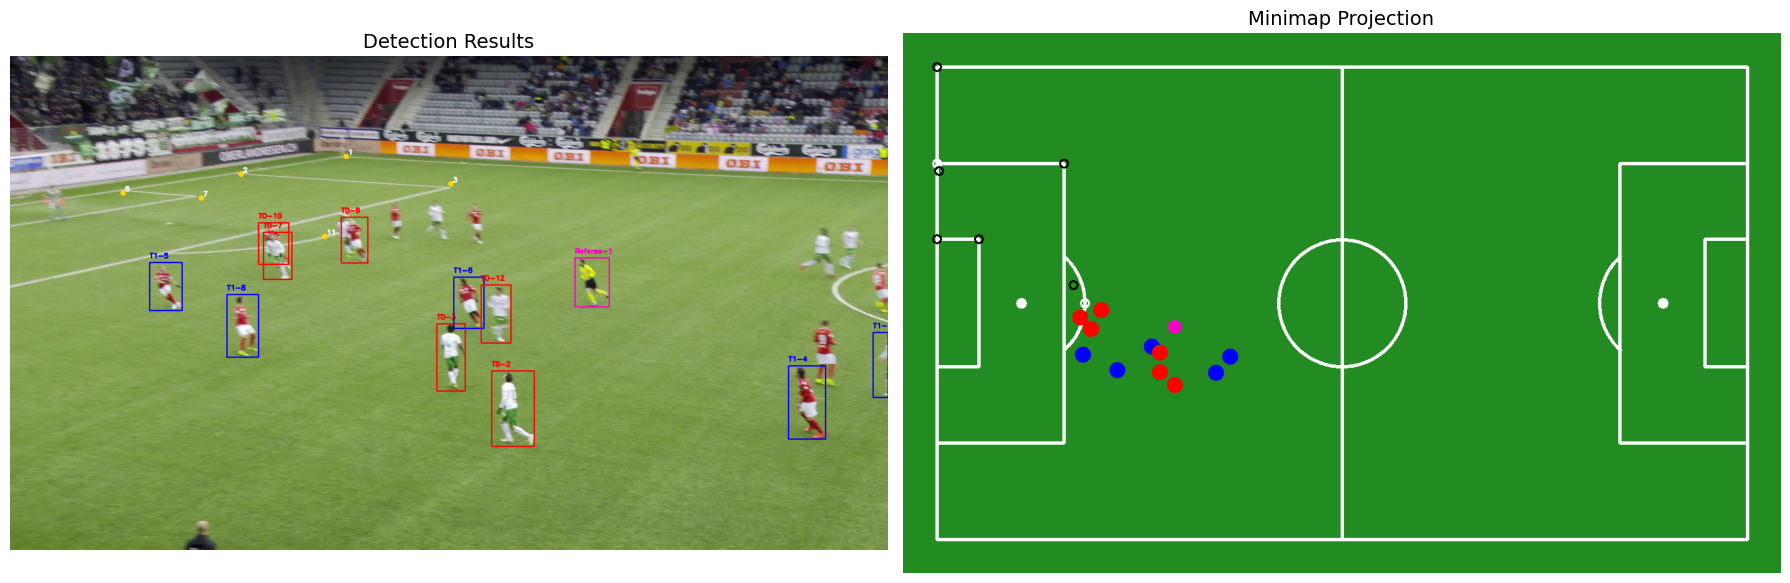

In [7]:
# ============================================================
# CONFIGURATION
# ============================================================

# Figure size for display
FIGURE_WIDTH = 18
FIGURE_HEIGHT = 8

# ============================================================
# CODE
# ============================================================

if IMAGE_PATH:
    # Display results side by side
    fig, axes = plt.subplots(1, 2, figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
    
    # Annotated frame
    axes[0].imshow(cv2.cvtColor(result['frame'], cv2.COLOR_BGR2RGB))
    axes[0].set_title("Detection Results", fontsize=14)
    axes[0].axis("off")
    
    # Minimap
    axes[1].imshow(cv2.cvtColor(result['minimap'], cv2.COLOR_BGR2RGB))
    axes[1].set_title("Minimap Projection", fontsize=14)
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

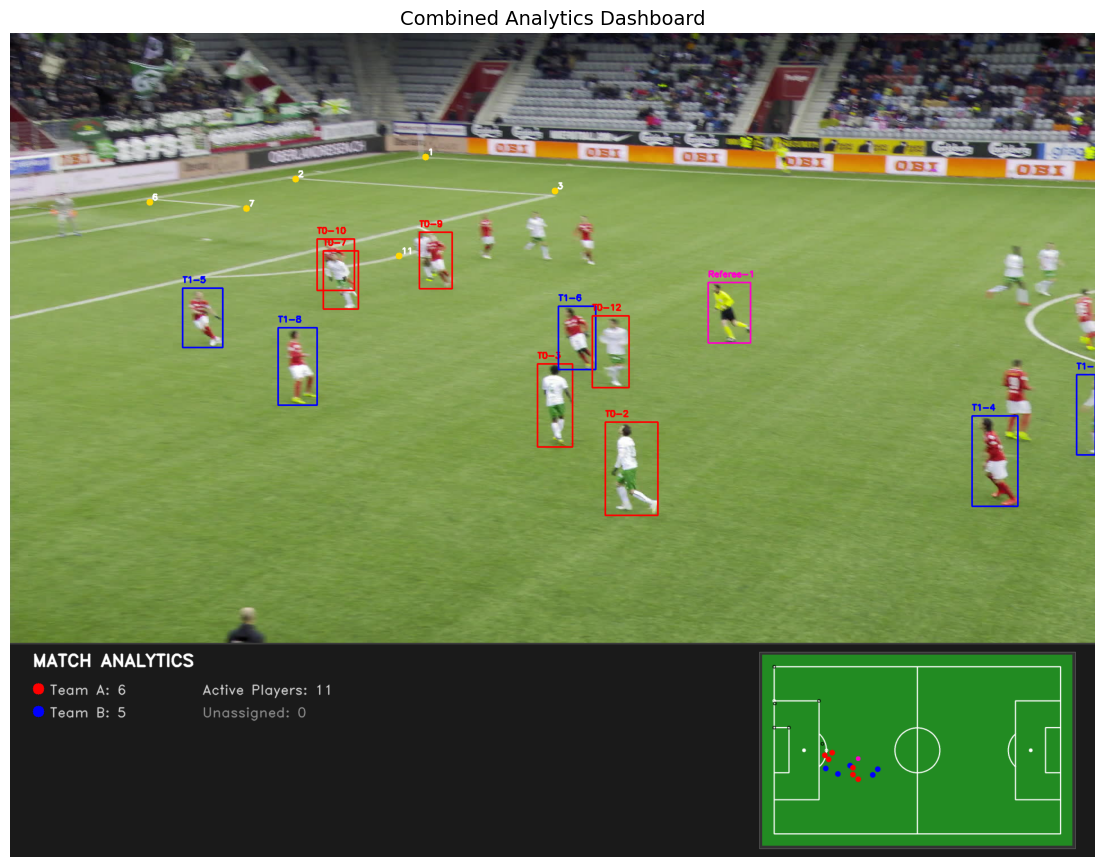

In [8]:
# ============================================================
# CONFIGURATION
# ============================================================

# Figure size for combined view
COMBINED_FIGURE_WIDTH = 14
COMBINED_FIGURE_HEIGHT = 12

# ============================================================
# CODE
# ============================================================

if IMAGE_PATH:
    # Create and display split view (now improved with stats)
    split_view = compose_split_view(
        frame=result['frame'], 
        minimap=result['minimap'],
        stats=result['stats']  # Pass stats for dashboard
    )
    
    plt.figure(figsize=(COMBINED_FIGURE_WIDTH, COMBINED_FIGURE_HEIGHT))
    plt.imshow(cv2.cvtColor(split_view, cv2.COLOR_BGR2RGB))
    plt.title("Combined Analytics Dashboard", fontsize=14)
    plt.axis("off")
    plt.show()

---

## 5. Full Video Processing

In [9]:
# ============================================================
# CONFIGURATION
# ============================================================

# Input video path
# Set to None to use default sample video
INPUT_VIDEO_PATH = None  # e.g., r"D:\Videos\match.mp4"

# Output video path
# Set to None to auto-generate based on input
OUTPUT_VIDEO_PATH = None  # e.g., r"D:\Videos\match_output.mp4"

# Processing options
START_FRAME = 0  # Frame to start processing from
END_FRAME = None  # Frame to end processing (None = process all)
FRAME_SKIP = 1  # Process every Nth frame (1 = all frames, 2 = every other frame)

# Detection settings
VIDEO_CONFIDENCE = 0.65

# Visualization settings
VIDEO_SHOW_DETECTION = True
VIDEO_SHOW_CLUSTERING = True
VIDEO_SHOW_IDS = True
VIDEO_SHOW_KEYPOINTS = True

# Output settings
OUTPUT_FPS = None  # None = same as input
OUTPUT_CODEC = "mp4v"  # Video codec (mp4v, XVID, etc.)

# Team color initialization
# Number of random frames to sample for initial team color clustering
NUM_INIT_FRAMES = 100

# ============================================================
# CODE
# ============================================================

# Auto-detect input video if not specified
if INPUT_VIDEO_PATH is None:
    default_video = DATASET_DIR / "Video.mp4"
    if default_video.exists():
        INPUT_VIDEO_PATH = str(default_video)
        print(f"Using default video: {INPUT_VIDEO_PATH}")
    else:
        print(f"❌ Default video not found: {default_video}")
        print("Please set INPUT_VIDEO_PATH manually.")

# Auto-generate output path if not specified
if INPUT_VIDEO_PATH and OUTPUT_VIDEO_PATH is None:
    input_path = Path(INPUT_VIDEO_PATH)
    OUTPUT_VIDEO_PATH = str(input_path.parent / f"{input_path.stem}_processed{input_path.suffix}")
    print(f"Output will be saved to: {OUTPUT_VIDEO_PATH}")

# Validate input video
if INPUT_VIDEO_PATH:
    if Path(INPUT_VIDEO_PATH).exists():
        cap = cv2.VideoCapture(INPUT_VIDEO_PATH)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        cap.release()
        
        print(f"\n📹 Video Info:")
        print(f"   Resolution: {width}x{height}")
        print(f"   FPS: {fps}")
        print(f"   Total frames: {total_frames}")
        print(f"   Duration: {total_frames/fps:.1f} seconds")
    else:
        print(f"❌ Video file not found: {INPUT_VIDEO_PATH}")
        INPUT_VIDEO_PATH = None

Using default video: D:\Project\FootballAnalytix\Data\Sample\Video.mp4
Output will be saved to: D:\Project\FootballAnalytix\Data\Sample\Video_processed.mp4

📹 Video Info:
   Resolution: 1920x1080
   FPS: 25.0
   Total frames: 750
   Duration: 30.0 seconds


In [10]:
# ============================================================
# CONFIGURATION
# ============================================================

# Uses configuration from previous cell

# ============================================================
# CODE
# ============================================================

if INPUT_VIDEO_PATH:
    print("Initializing processing state from video...")
    
    # Initialize state by sampling random frames for team color clustering
    video_state = initialize_combined_state(
        video_path=Path(INPUT_VIDEO_PATH),
        model=players_model,
        num_frames=NUM_INIT_FRAMES,
        conf=VIDEO_CONFIDENCE,
    )
    
    if video_state.has_team_colors():
        print("\n✅ Team colors initialized successfully!")
        print(f"   Team color centers (RGB): {video_state.team_color_centers}")
    else:
        print("\n⚠️ Team colors will be initialized during processing.")
else:
    print("⚠️ No input video specified. Skipping initialization.")

Initializing processing state from video...
Team color centers (RGB):
 [[     158.57      169.95      133.34]
 [     147.35      127.88      87.802]]

✅ Team colors initialized successfully!
   Team color centers (RGB): [[     158.57      169.95      133.34]
 [     147.35      127.88      87.802]]


In [11]:
# ============================================================
# CONFIGURATION
# ============================================================

# Uses configuration from previous cells

# ============================================================
# CODE
# ============================================================

if INPUT_VIDEO_PATH:
    print(f"Starting video processing...")
    print(f"Input: {INPUT_VIDEO_PATH}")
    print(f"Output: {OUTPUT_VIDEO_PATH}")
    
    # Open input video
    cap = cv2.VideoCapture(INPUT_VIDEO_PATH)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    input_fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Calculate output dimensions (frame + dashboard)
    # We use a 35% height dashboard now, so total height = 1.35 * frame_height
    dashboard_height = int(height * 0.35)
    output_height = height + dashboard_height
    output_width = width
    
    # Set up output video
    out_fps = OUTPUT_FPS if OUTPUT_FPS else input_fps
    fourcc = cv2.VideoWriter_fourcc(*OUTPUT_CODEC)
    out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, out_fps, (output_width, output_height))
    
    # Determine frame range
    start = START_FRAME
    end = END_FRAME if END_FRAME else total_frames
    end = min(end, total_frames)
    
    # Seek to start frame
    if start > 0:
        cap.set(cv2.CAP_PROP_POS_FRAMES, start)
    
    frames_to_process = (end - start) // FRAME_SKIP
    print(f"\nProcessing frames {start} to {end} (every {FRAME_SKIP} frame(s))")
    print(f"Total frames to process: {frames_to_process}")
    
    # Process frames
    frame_idx = start
    processed_count = 0
    
    with tqdm(total=frames_to_process, desc="Processing", unit="frame") as pbar:
        while frame_idx < end:
            ret, frame = cap.read()
            if not ret:
                break
            
            # Process frame
            result = process_combined_frame(
                frame=frame,
                frame_idx=frame_idx,
                state=video_state,
                players_model=players_model,
                field_model=field_model,
                config=pitch_config,
                conf=VIDEO_CONFIDENCE,
                show_object_detection=VIDEO_SHOW_DETECTION,
                show_clustering=VIDEO_SHOW_CLUSTERING,
                show_id=VIDEO_SHOW_IDS,
                show_detected_vertices=VIDEO_SHOW_KEYPOINTS,
                base_minimap=base_minimap.copy(),
            )
            
            # Compose split view (using new stats dashboard)
            split_view = compose_split_view(
                frame=result['frame'],
                minimap=result['minimap'],
                stats=result['stats']
            )
            
            # Write frame
            out.write(split_view)
            
            processed_count += 1
            pbar.update(1)
            pbar.set_postfix({
                "T0": result['stats']['team_0'],
                "T1": result['stats']['team_1'],
                "tracked": result['stats']['tracked'],
            })
            
            # Skip frames if needed
            frame_idx += FRAME_SKIP
            if FRAME_SKIP > 1:
                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    
    # Cleanup
    cap.release()
    out.release()
    
    print(f"\n✅ Processing complete!")
    print(f"   Processed {processed_count} frames")
    print(f"   Total tracked players: {len(video_state.player_teams)}")
    print(f"   Output saved to: {OUTPUT_VIDEO_PATH}")
else:
    print("⚠️ No input video specified. Skipping video processing.")

Starting video processing...
Input: D:\Project\FootballAnalytix\Data\Sample\Video.mp4
Output: D:\Project\FootballAnalytix\Data\Sample\Video_processed.mp4

Processing frames 0 to 750 (every 1 frame(s))
Total frames to process: 750


Processing:   0%|          | 0/750 [00:00<?, ?frame/s]


✅ Processing complete!
   Processed 750 frames
   Total tracked players: 39
   Output saved to: D:\Project\FootballAnalytix\Data\Sample\Video_processed.mp4


---

## 6. Batch Process Multiple Frames (Preview)

Generating preview of 6 frames...
Initialized team colors using 2 accumulated samples.


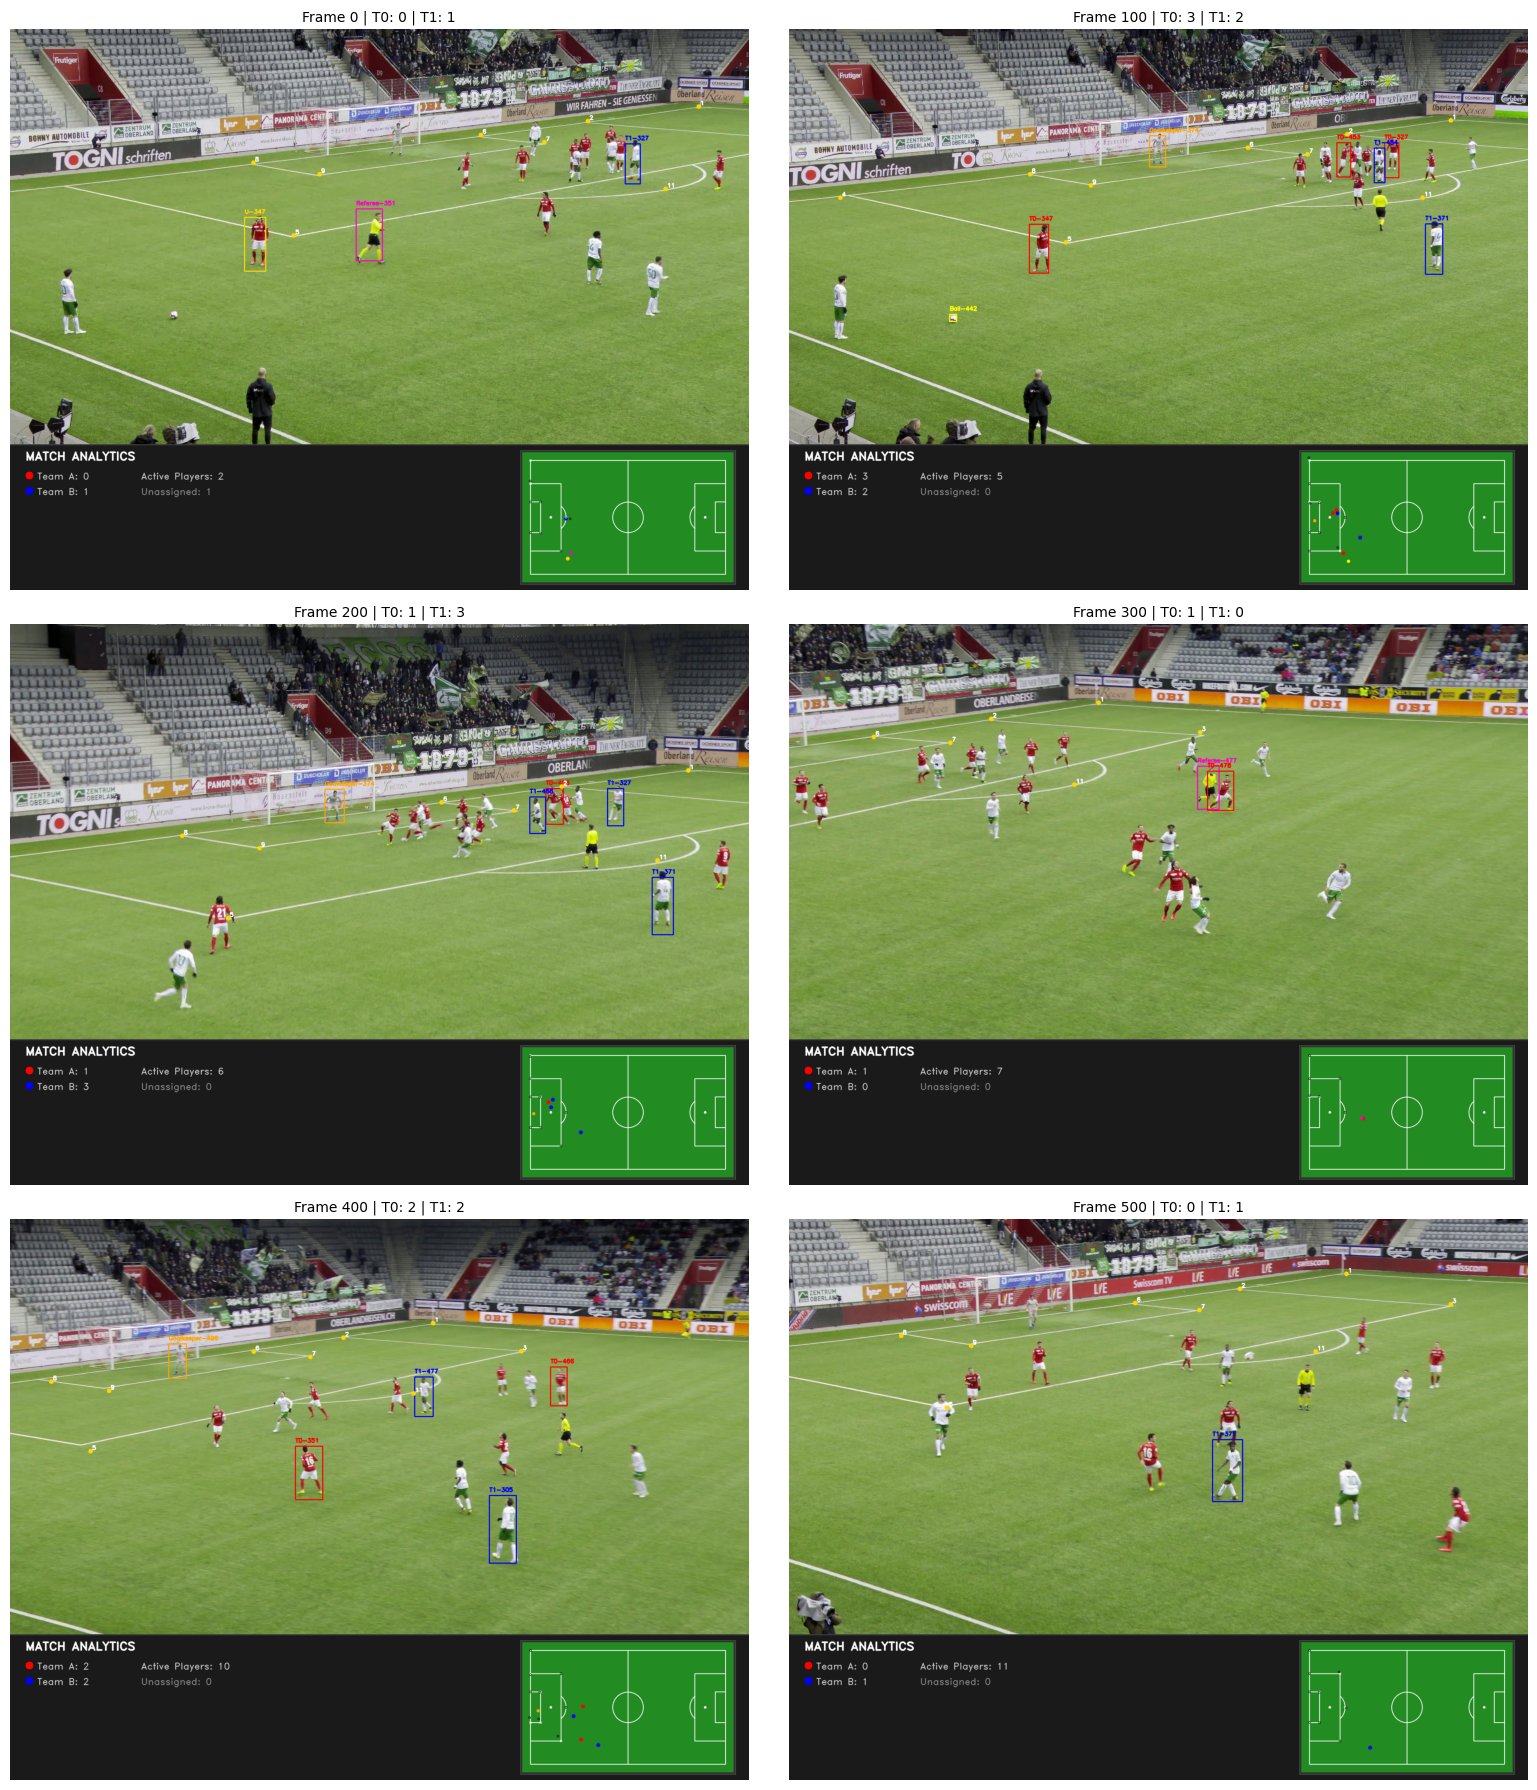


✅ Preview complete! Sampled frames: [0, 100, 200, 300, 400, 500]


In [12]:
# ============================================================
# CONFIGURATION
# ============================================================

# Number of frames to preview
NUM_PREVIEW_FRAMES = 6

# Frame interval for preview (sample every Nth frame)
PREVIEW_INTERVAL = 100

# Figure size for preview grid
PREVIEW_COLS = 2
PREVIEW_FIG_WIDTH = 16
PREVIEW_FIG_HEIGHT = 6

# ============================================================
# CODE
# ============================================================

if INPUT_VIDEO_PATH:
    print(f"Generating preview of {NUM_PREVIEW_FRAMES} frames...")
    
    cap = cv2.VideoCapture(INPUT_VIDEO_PATH)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Calculate frame indices to sample
    sample_indices = list(range(0, total_frames, PREVIEW_INTERVAL))[:NUM_PREVIEW_FRAMES]
    
    # Create fresh state for preview
    preview_state = CombinedState()
    
    # Collect previews
    previews = []
    for idx in sample_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        
        result = process_combined_frame(
            frame=frame,
            frame_idx=idx,
            state=preview_state,
            players_model=players_model,
            field_model=field_model,
            config=pitch_config,
            base_minimap=base_minimap.copy(),
        )
        
        previews.append({
            "idx": idx,
            "frame": result['frame'],
            "minimap": result['minimap'],
            "stats": result['stats'],
        })
    
    cap.release()
    
    # Display previews
    num_rows = (len(previews) + PREVIEW_COLS - 1) // PREVIEW_COLS
    fig, axes = plt.subplots(num_rows, PREVIEW_COLS, figsize=(PREVIEW_FIG_WIDTH, PREVIEW_FIG_HEIGHT * num_rows))
    axes = np.atleast_2d(axes)
    
    for i, preview in enumerate(previews):
        row = i // PREVIEW_COLS
        col = i % PREVIEW_COLS
        
        combined = compose_split_view(preview['frame'], preview['minimap'], stats=preview['stats'])
        axes[row, col].imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
        axes[row, col].set_title(
            f"Frame {preview['idx']} | T0: {preview['stats']['team_0']} | T1: {preview['stats']['team_1']}",
            fontsize=10
        )
        axes[row, col].axis("off")
    
    # Hide empty subplots
    for i in range(len(previews), num_rows * PREVIEW_COLS):
        row = i // PREVIEW_COLS
        col = i % PREVIEW_COLS
        axes[row, col].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Preview complete! Sampled frames: {sample_indices}")
else:
    print("⚠️ No input video specified. Skipping preview.")

---

## 7. Library Information

In [13]:
# ============================================================
# CONFIGURATION
# ============================================================

# No configuration needed

# ============================================================
# CODE
# ============================================================

import footballanalytix

print(f"📦 FootballAnalytix Library")
print(f"   Version: {footballanalytix.__version__}")
print(f"   Project Root: {footballanalytix.PROJECT_ROOT}")
print(f"")
print(f"📂 Available Exports ({len(footballanalytix.__all__)} total):")

# Group exports by category
categories = {
    "Config": ["PROJECT_ROOT", "MODELS_DIR", "DATA_DIR", "DATASET_DIR", "PLAYERS_MODEL_PATH", "FIELD_MODEL_PATH", 
               "DEFAULT_VIDEO_PATH", "CLEANED_DATASET_DIR", "MINIMAP_SCALE", "MINIMAP_PADDING", 
               "TEAM_COLORS_BGR", "UNASSIGNED_COLOR", "CONFIDENCE_THRESHOLD", "REASSIGN_INTERVAL", 
               "MAX_COLOR_SAMPLES", "CLASS_CONFIG", "CLASS_ID_LOOKUP"],
    "State": ["CombinedState"],
    "Models": ["load_players_model", "load_field_model", "get_model_label"],
    "Players": ["extract_jersey_color", "collect_initial_team_colors", "assign_player_team", 
                "reassign_all_teams", "resolve_class_metadata"],
    "Field": ["KEYPOINT_NAMES", "SoccerPitchConfiguration", "ViewTransformer", 
              "detect_field_keypoints", "compute_view_transformers"],
    "Visualization": ["bgr_to_rgb_norm", "draw_pitch", "compose_split_view", "minimap_coords", "create_annotators"],
    "Pipeline": ["initialize_combined_state", "create_state_from_frame", "process_combined_frame"],
}

for category, items in categories.items():
    print(f"\n   {category}:")
    for item in items:
        if item in footballanalytix.__all__:
            print(f"      - {item}")

📦 FootballAnalytix Library
   Version: 1.0.0
   Project Root: D:\Project\FootballAnalytix

📂 Available Exports (40 total):

   Config:
      - PROJECT_ROOT
      - MODELS_DIR
      - DATA_DIR
      - DATASET_DIR
      - PLAYERS_MODEL_PATH
      - FIELD_MODEL_PATH
      - DEFAULT_VIDEO_PATH
      - CLEANED_DATASET_DIR
      - MINIMAP_SCALE
      - MINIMAP_PADDING
      - TEAM_COLORS_BGR
      - UNASSIGNED_COLOR
      - CONFIDENCE_THRESHOLD
      - REASSIGN_INTERVAL
      - MAX_COLOR_SAMPLES
      - CLASS_CONFIG
      - CLASS_ID_LOOKUP

   State:
      - CombinedState

   Models:
      - load_players_model
      - load_field_model
      - get_model_label

   Players:
      - extract_jersey_color
      - collect_initial_team_colors
      - assign_player_team
      - reassign_all_teams
      - resolve_class_metadata

   Field:
      - KEYPOINT_NAMES
      - SoccerPitchConfiguration
      - ViewTransformer
      - detect_field_keypoints
      - compute_view_transformers

   Visualization:
 